# Modelagem Preditiva da Satisfação do Cliente

Este notebook apresenta a construção de uma solução de Machine Learning voltada à identificação de clientes com maior risco de insatisfação.

A proposta vai além do treinamento de modelos: o objetivo é transformar dados sobre perfil, pedido, entrega e atendimento em informações capazes de apoiar decisões de retenção no e-commerce.

Ao longo do notebook serão desenvolvidas as seguintes etapas:

- definição da variável-alvo;
- criação de atributos derivados;
- divisão entre treino e teste;
- pré-processamento dos dados;
- comparação de diferentes algoritmos;
- otimização de hiperparâmetros;
- avaliação e seleção do modelo final;
- transformação das previsões em ações de negócio.

Como a base apresenta desbalanceamento entre as classes, a avaliação será orientada por métricas que consideram o desempenho global e o equilíbrio entre os grupos, como F1 Macro, balanced accuracy, recall e matriz de confusão.

> O resultado esperado é uma solução capaz não apenas de prever clientes detratores, mas também de apoiar a priorização de atendimentos e estratégias de recuperação.

#1. Preparação do ambiente

Nesta etapa serão importadas as bibliotecas utilizadas para manipulação dos dados, pré-processamento, treinamento, avaliação e salvamento dos modelos.

In [1]:
# ================================
# Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# Visualização de dados
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Salvamento de modelos
# ================================
import joblib

# ================================
# Divisão dos dados
# ================================
from sklearn.model_selection import train_test_split

# ================================
# Pré-processamento
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ================================
# Modelos de Machine Learning
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ================================
# Avaliação de modelos
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# ================================
# Validação e otimização
# ================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_validate, StratifiedKFold

# 2. Leitura da base tratada

Nesta etapa será carregada a base preparada no notebook de entendimento e tratamento dos dados.

Como as etapas de limpeza, tradução das colunas, verificação de valores ausentes, análise de duplicidades e seleção inicial de variáveis já foram realizadas anteriormente, este notebook utilizará diretamente a versão tratada da base.

Após o carregamento, serão exibidas as primeiras observações para confirmar que o arquivo foi lido corretamente.

In [2]:
dados = pd.read_csv('/content/clientes_tratados.csv')
dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,nps,numero_reclamacoes
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,3
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,3
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,7
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,4
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,3


# 3. Validação rápida dos dados

Antes de iniciar a modelagem, será realizada uma verificação rápida da base para confirmar se sua estrutura permanece consistente após o processo de tratamento.

Nesta etapa serão conferidos:

- a quantidade de registros e variáveis;
- os tipos das colunas;
- a presença de valores ausentes;
- a existência de registros duplicados.

Essa validação funciona como um controle de qualidade antes da criação das features e do treinamento dos modelos.

In [3]:
print(f'Total de linhas: {dados.shape[0]}')
print(f'Total de colunas: {dados.shape[1]}')

Total de linhas: 2500
Total de colunas: 15


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade_cliente         2500 non-null   int64  
 1   regiao_cliente        2500 non-null   object 
 2   tempo_cliente_meses   2500 non-null   int64  
 3   valor_pedido          2500 non-null   float64
 4   quantidade_itens      2500 non-null   int64  
 5   valor_desconto        2500 non-null   float64
 6   parcelas_pagamento    2500 non-null   int64  
 7   tempo_entrega_dias    2500 non-null   int64  
 8   atraso_entrega_dias   2500 non-null   int64  
 9   valor_frete           2500 non-null   float64
 10  tentativas_entrega    2500 non-null   int64  
 11  contatos_atendimento  2500 non-null   int64  
 12  tempo_resolucao_dias  2500 non-null   int64  
 13  nps                   2500 non-null   float64
 14  numero_reclamacoes    2500 non-null   int64  
dtypes: float64(4), int64(

In [5]:
print(f'Valores Ausentes: {dados.isna().sum().sum()}')
print(f'Valores Duplicados: {dados.duplicated().sum()}')

Valores Ausentes: 0
Valores Duplicados: 0


#4. Definição da variável-alvo

Nesta etapa, a nota de NPS será transformada em uma variável binária para representar o risco de insatisfação do cliente.

A classificação será definida da seguinte forma:

- `1`: cliente detrator, com nota de NPS entre 0 e 6;
- `0`: cliente não detrator, com nota de NPS acima de 6.

Essa transformação permite tratar o problema como uma tarefa de classificação binária, na qual o objetivo será identificar clientes com maior probabilidade de insatisfação.

In [6]:
# transformando em 0 e 1 - valores 1 representam os detratores
dados['target'] = pd.cut(dados['nps'],
                         bins=[-1, 6., np.inf],
                         labels=[1, 0])

In [7]:
dados['target'].value_counts()

,count
target,
1,1851
0,649


In [8]:
# Fazendo o drop do nps agora, já que iremos utilizar a target
dados = dados.drop('nps', axis=1)

# 5. Engenharia de atributos

Com base nos padrões identificados durante a análise exploratória, serão criadas novas variáveis para representar situações críticas na experiência do cliente.

As variáveis derivadas são:

- `atraso_critico`: indica atrasos iguais ou superiores a 2 dias;
- `problema_complexo`: identifica situações com pelo menos 2 contatos com o atendimento e tempo de resolução igual ou superior a 3 dias;
- `reclamacao_recorrente`: indica clientes com 3 ou mais reclamações.

Essas novas features resumem comportamentos relevantes e poderão ajudar os modelos a identificar padrões associados à insatisfação.

In [9]:
dados['atraso_critico'] = (dados['atraso_entrega_dias'] >= 2).astype(int)

dados['problema_complexo'] = (
    (dados['contatos_atendimento'] >= 2) &
    (dados['tempo_resolucao_dias'] >= 3)
).astype(int)

dados['reclamacao_recorrente'] = (dados['numero_reclamacoes'] >= 3).astype(int)

In [10]:
dados.head()

,idade_cliente,regiao_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,target,atraso_critico,problema_complexo,reclamacao_recorrente
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,3,0,1,0,1
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,3,1,1,0,1
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,7,1,0,1,1
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,4,1,1,0,1
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,3,0,0,0,1


# 6. Divisão dos dados em treino e teste

Nesta etapa, o conjunto de dados será separado entre variáveis explicativas e variável-alvo.

- `X`: contém as variáveis utilizadas pelos modelos;
- `y`: contém a variável `target`, que indica se o cliente é detrator.

Em seguida, os dados serão divididos em conjuntos de treino e teste.

O conjunto de treino será utilizado para ajustar os modelos, enquanto o conjunto de teste será reservado para a avaliação final.

A divisão será estratificada pela variável-alvo, preservando a proporção de clientes detratores e não detratores nos dois conjuntos.

In [11]:
X = dados.drop('target', axis=1)
y = dados['target']

In [12]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)

In [13]:
print(f'Treino: {X_treino.shape[0]}')
print(f'Teste: {X_teste.shape[0]}')

Treino: 2000
Teste: 500


In [14]:
colunas_entrada = X_treino.columns

In [15]:
df = X_teste.copy()

# 7. Pré-processamento dos dados

Nesta etapa, as variáveis serão preparadas para o treinamento dos modelos.

As colunas numéricas serão padronizadas com `StandardScaler`, enquanto a variável categórica `regiao_cliente` será transformada por meio de One-Hot Encoding.

A padronização é importante para modelos sensíveis à escala, como Regressão Logística, KNN e SVM. Já o One-Hot Encoding converte categorias textuais em colunas numéricas, permitindo seu uso pelos algoritmos.

O pré-processador será ajustado somente com os dados de treino e depois aplicado ao conjunto de teste, evitando vazamento de informações.

In [16]:
col_numericas = ['idade_cliente', 'tempo_cliente_meses', 'valor_pedido', 'quantidade_itens', 'valor_desconto', 'parcelas_pagamento', 'tempo_entrega_dias', 'atraso_entrega_dias',
             'valor_frete', 'tentativas_entrega', 'contatos_atendimento', 'tempo_resolucao_dias', 'numero_reclamacoes', 'atraso_critico', 'problema_complexo', 'reclamacao_recorrente']
col_categoricas = ['regiao_cliente']

In [17]:
full_pipeline = ColumnTransformer([
    ("num", StandardScaler(), col_numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False), col_categoricas)
])

In [18]:
x_treino_tratado = full_pipeline.fit_transform(X_treino)
x_teste_tratado = full_pipeline.transform(X_teste)

In [19]:
num_cols = list(col_numericas)
cat_cols = full_pipeline.named_transformers_['cat'].get_feature_names_out(col_categoricas)

X_treino = pd.DataFrame(x_treino_tratado, columns=num_cols + list(cat_cols))
X_teste = pd.DataFrame(x_teste_tratado, columns=num_cols + list(cat_cols))

In [20]:
X_treino.head()

,idade_cliente,tempo_cliente_meses,valor_pedido,quantidade_itens,valor_desconto,parcelas_pagamento,tempo_entrega_dias,atraso_entrega_dias,valor_frete,tentativas_entrega,contatos_atendimento,tempo_resolucao_dias,numero_reclamacoes,atraso_critico,problema_complexo,reclamacao_recorrente,regiao_cliente_Nordeste,regiao_cliente_Norte,regiao_cliente_Sudeste,regiao_cliente_Sul
0,-1.228616,-1.060464,-0.323005,-1.465588,0.012322,-1.582239,-1.081564,1.231576,-2.031869,-1.231045,-0.422476,-0.727218,-0.652053,0.745124,-0.730577,0.449359,0.0,0.0,0.0,1.0
1,0.911306,-0.275312,2.674934,0.315199,-0.949631,-0.625336,1.580419,0.550771,0.343444,-1.231045,1.215029,-0.436156,1.040859,0.745124,1.368782,0.449359,0.0,0.0,0.0,1.0
2,1.045051,0.335362,0.985016,0.315199,-0.814828,0.012599,-0.549167,-1.491644,-1.062387,-1.231045,2.033782,0.437030,2.169466,-1.342058,1.368782,0.449359,1.0,0.0,0.0,0.0
3,-0.225528,0.975115,-0.569380,-1.465588,0.345084,1.607438,-0.549167,-0.130034,-1.414255,1.222458,-0.422476,-0.727218,-1.216357,0.745124,-0.730577,-2.225395,0.0,0.0,0.0,1.0
4,-0.961126,-0.478870,-0.190397,0.908795,-0.289201,-0.306368,1.580419,1.231576,0.326220,-0.004294,-0.422476,-1.309342,-0.087749,0.745124,-0.730577,0.449359,0.0,0.0,1.0,0.0


# 8. Treinamento e comparação inicial dos modelos

Nesta etapa, diferentes algoritmos de classificação serão treinados utilizando os mesmos conjuntos de treino e teste.

Foram selecionados modelos com características distintas:

- Regressão Logística;
- Árvore de Decisão;
- Random Forest;
- K-Nearest Neighbors;
- Support Vector Machine;
- Naive Bayes;
- Gradient Boosting.

O objetivo desta comparação inicial é identificar quais algoritmos apresentam melhor desempenho na classificação de clientes detratores e não detratores.

Como a base apresenta desbalanceamento entre as classes, a análise não será baseada somente na acurácia. Também serão avaliadas precision, recall e F1-score para cada classe.

In [21]:
modelos_classificacao = {
    "Regressão Logística": LogisticRegression(random_state=42, max_iter=2000, class_weight="balanced"),

    "Árvore de Decisão": DecisionTreeClassifier(random_state=42, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced",
        n_jobs=-1),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),

    "Naive Bayes": GaussianNB(),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [22]:
resultados = []

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, pred),
        "Precision_0": precision_score(y_teste, pred, pos_label=0),
        "Precision_1": precision_score(y_teste, pred, pos_label=1),
        "Recall_0": recall_score(y_teste, pred, pos_label=0),
        "Recall_1": recall_score(y_teste, pred, pos_label=1),
        "F1-score": f1_score(y_teste, pred)
    })

resultados_df = pd.DataFrame(resultados).sort_values(by="F1-score", ascending=False)
print("====== Resultados dos Modelos Ordenados por F1-Score ======\n")
resultados_df.round(3)

====== Resultados dos Modelos Ordenados por F1-Score ======



,Modelo,Accuracy,Precision_0,Precision_1,Recall_0,Recall_1,F1-score
2,Random Forest,0.838,0.743,0.862,0.577,0.930,0.895
6,Gradient Boosting,0.836,0.735,0.862,0.577,0.927,0.893
3,KNN,0.800,0.647,0.839,0.508,0.903,0.870
5,Naive Bayes,0.808,0.620,0.883,0.677,0.854,0.868
1,Árvore de Decisão,0.778,0.586,0.833,0.500,0.876,0.854
0,Regressão Logística,0.798,0.580,0.922,0.808,0.795,0.853
4,SVM,0.794,0.574,0.921,0.808,0.789,0.850


In [23]:
# Selecionando o top3 modelos
for nome in['Random Forest', 'Gradient Boosting', 'KNN']:
  modelo = modelos_classificacao[nome]
  modelo.fit(X_treino, y_treino)
  pred = modelo.predict(X_teste)

  print(f'\n\nModelo: {nome}')
  print(classification_report(y_teste, pred))



Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.74      0.58      0.65       130
           1       0.86      0.93      0.89       370

    accuracy                           0.84       500
   macro avg       0.80      0.75      0.77       500
weighted avg       0.83      0.84      0.83       500



Modelo: Gradient Boosting
              precision    recall  f1-score   support

           0       0.74      0.58      0.65       130
           1       0.86      0.93      0.89       370

    accuracy                           0.84       500
   macro avg       0.80      0.75      0.77       500
weighted avg       0.83      0.84      0.83       500



Modelo: KNN
              precision    recall  f1-score   support

           0       0.65      0.51      0.57       130
           1       0.84      0.90      0.87       370

    accuracy                           0.80       500
   macro avg       0.74      0.71      0.72       500
weighted

### Comparação inicial dos modelos

Os resultados mostram que Random Forest e Gradient Boosting apresentaram os maiores valores de F1-score para a classe detratora, além das maiores acurácias gerais.

O Random Forest obteve acurácia de 83,8% e recall de 93,0% para a classe detratora. O Gradient Boosting apresentou resultado semelhante, com acurácia de 83,6% e recall de 92,7%.

O KNN apresentou o terceiro maior F1-score da classe positiva, porém teve recall de apenas 50,8% para a classe não detratora. Isso indica maior dificuldade para reconhecer corretamente os clientes pertencentes à classe minoritária.

A Regressão Logística e o SVM apresentaram menor acurácia geral, mas alcançaram recall próximo de 80,8% para a classe não detratora, demonstrando um comportamento mais equilibrado entre os dois grupos.

Por esse motivo, a seleção dos melhores modelos não deve considerar apenas o F1-score da classe detratora. Também serão observados o F1-score macro e a acurácia balanceada, que atribuem maior importância ao desempenho nas duas classes.

# 9. Otimização de hiperparâmetros

Após a comparação inicial dos algoritmos, foram selecionados Gradient Boosting, Random Forest e KNN para a etapa de otimização.

O objetivo é buscar combinações de hiperparâmetros capazes de melhorar o desempenho e a capacidade de generalização dos modelos.

A otimização será realizada com `RandomizedSearchCV`, utilizando validação cruzada com cinco divisões e F1 Macro como métrica principal, já que essa métrica considera o desempenho das duas classes de forma equilibrada.

In [24]:
# Modelos a serem utilizados
gb_model = GradientBoostingClassifier(random_state=42)

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

knn_model = KNeighborsClassifier()

### Espaços de busca

Para cada algoritmo, foram definidos conjuntos de hiperparâmetros relacionados à complexidade, regularização e comportamento do modelo.

O `RandomizedSearchCV` testará diferentes combinações dentro desses espaços, reduzindo o custo computacional em comparação com uma busca exaustiva.

In [25]:
# Params Gradient Boosting
param_dist_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}
# Params Random Forest
param_dist_rf = {
    'n_estimators': [200, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 'log2']
}
# Parâmetros do KNN
param_dist_knn = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2],
    "leaf_size": [15, 30, 45, 60]
}

In [26]:
random_gb = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist_gb,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist_knn,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

### Execução da otimização

As buscas serão ajustadas utilizando apenas o conjunto de treino.

Ao final, será selecionada a combinação de hiperparâmetros que apresentar o melhor desempenho médio durante a validação cruzada.

In [27]:
random_gb.fit(X_treino, y_treino)
random_rf.fit(X_treino, y_treino)
random_knn.fit(X_treino, y_treino)

print("Gradient Boosting - melhores parâmetros:")
print(random_gb.best_params_)
print()

print("Random Forest - melhores parâmetros:")
print(random_rf.best_params_)
print()

print("KNN - melhores parâmetros:")
print(random_knn.best_params_)
print()

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Gradient Boosting - melhores parâmetros:
{'subsample': 0.9, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.05}

Random Forest - melhores parâmetros:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}

KNN - melhores parâmetros:
{'weights': 'distance', 'p': 1, 'n_neighbors': 7, 'metric': 'euclidean', 'leaf_size': 60}



### Avaliação dos modelos otimizados

Após a otimização, os melhores estimadores serão avaliados no conjunto de teste.

Serão analisadas métricas como acurácia, precision, recall e F1-score para cada classe.

Nesta etapa, os resultados serão apenas registrados. A escolha do modelo final será realizada posteriormente, após a comparação visual apresentada na próxima seção.

In [28]:
modelos_tunados = {
    "Gradient Boosting Tunado": random_gb.best_estimator_,
    "Random Forest Tunado": random_rf.best_estimator_,
    "KNN Tunado": random_knn.best_estimator_
}

resultados_tuning = []

for nome, modelo in modelos_tunados.items():
    pred = modelo.predict(X_teste)

    resultados_tuning.append({
      'Modelo': nome,
      'Acurácia': accuracy_score(y_teste, pred),
      'Recall_0': recall_score(y_teste, pred, pos_label=0),
      'Recall_1': recall_score(y_teste, pred, pos_label=1),
      'Precision_0': precision_score(y_teste, pred, pos_label=0),
      'Precision_1': precision_score(y_teste, pred, pos_label=1),
      'F1-Score': f1_score(y_teste, pred)
    })

resultados_tuning_df = pd.DataFrame(resultados_tuning).sort_values(
    by="F1-Score", ascending=False
)

resultados_tuning_df.round(4)

,Modelo,Acurácia,Recall_0,Recall_1,Precision_0,Precision_1,F1-Score
0,Gradient Boosting Tunado,0.834,0.5923,0.9189,0.7196,0.8651,0.8912
1,Random Forest Tunado,0.832,0.7000,0.8784,0.6691,0.8929,0.8856
2,KNN Tunado,0.800,0.5154,0.9000,0.6442,0.8409,0.8695


In [29]:
for nome in ["Gradient Boosting Tunado", "Random Forest Tunado", "KNN Tunado"]:
    modelo = modelos_tunados[nome]
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)

    print(f"\n=== {nome} ===")
    print(classification_report(y_teste, pred))


=== Gradient Boosting Tunado ===
              precision    recall  f1-score   support

           0       0.72      0.59      0.65       130
           1       0.87      0.92      0.89       370

    accuracy                           0.83       500
   macro avg       0.79      0.76      0.77       500
weighted avg       0.83      0.83      0.83       500


=== Random Forest Tunado ===
              precision    recall  f1-score   support

           0       0.67      0.70      0.68       130
           1       0.89      0.88      0.89       370

    accuracy                           0.83       500
   macro avg       0.78      0.79      0.78       500
weighted avg       0.83      0.83      0.83       500


=== KNN Tunado ===
              precision    recall  f1-score   support

           0       0.64      0.52      0.57       130
           1       0.84      0.90      0.87       370

    accuracy                           0.80       500
   macro avg       0.74      0.71      0.72 

### Síntese da otimização

A otimização gerou versões ajustadas dos modelos Gradient Boosting, Random Forest e KNN.

Os resultados mostram diferenças no equilíbrio entre a identificação das classes `0` e `1`, mas ainda não será realizada a escolha definitiva do modelo.

Na próxima etapa, as métricas serão comparadas visualmente para apoiar uma decisão mais clara e fundamentada.

# 10. Análise gráfica dos modelos otimizados

Nesta etapa, os modelos otimizados serão comparados por meio das matrizes de confusão e das curvas ROC.

As matrizes de confusão permitem observar como cada algoritmo classificou as classes `0` e `1`, enquanto a curva ROC avalia a capacidade de separação entre clientes detratores e não detratores em diferentes limiares de decisão.

A análise conjunta dessas visualizações será utilizada para apoiar a escolha do modelo final.

## Matrizes de confusão

As matrizes de confusão mostram os acertos e erros de classificação de cada modelo.

Neste projeto:

- `0` representa clientes não detratores;
- `1` representa clientes detratores.

Além do total de acertos, será observado o equilíbrio entre a identificação das duas classes.

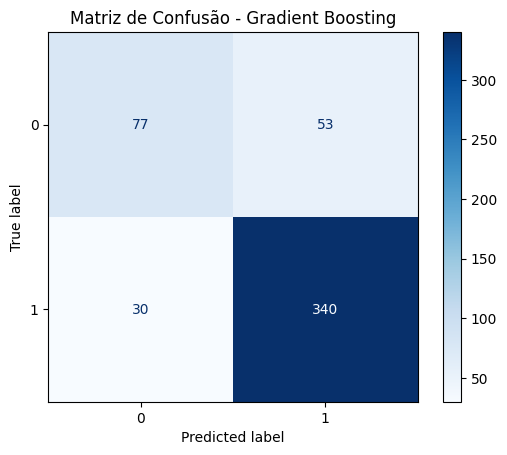

In [30]:
modelo_gb_final = random_gb.best_estimator_

y_pred_gb = modelo_gb_final.predict(X_teste)

ConfusionMatrixDisplay.from_estimator(modelo_gb_final, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Gradient Boosting')
plt.show()

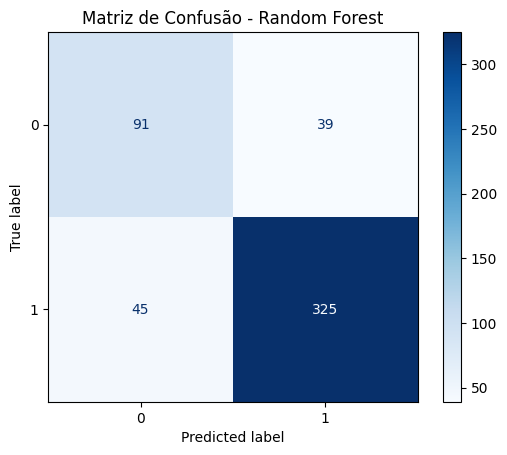

In [31]:
modelo_rf_final = random_rf.best_estimator_

y_pred_gb = modelo_rf_final.predict(X_teste)

ConfusionMatrixDisplay.from_estimator(modelo_rf_final, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

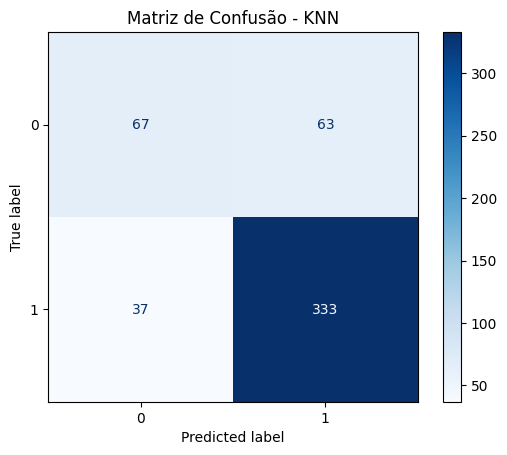

In [32]:
modelo_knn_final = random_knn.best_estimator_

y_pred_gb = modelo_knn_final.predict(X_teste)

ConfusionMatrixDisplay.from_estimator(modelo_knn_final, X_teste, y_teste, cmap='Blues')
plt.title('Matriz de Confusão - KNN')
plt.show()

### Interpretação das matrizes de confusão

O Gradient Boosting classificou corretamente 77 clientes não detratores e 340 detratores. O modelo apresentou forte capacidade de identificar detratores, mas classificou 53 clientes não detratores como detratores.

O Random Forest apresentou o melhor desempenho na classe `0`, identificando corretamente 91 clientes não detratores. Em contrapartida, deixou de identificar 45 clientes detratores.

O KNN identificou corretamente 333 detratores, porém apresentou a maior quantidade de erros na classe `0`, classificando 63 clientes não detratores como detratores.

De forma geral, o Gradient Boosting demonstrou maior sensibilidade para identificar clientes detratores, enquanto o Random Forest apresentou maior equilíbrio entre as duas classes.

## Curvas ROC

A curva ROC representa a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos em diferentes limites de classificação.

A área sob a curva, conhecida como AUC, varia entre 0 e 1. Quanto maior o valor, maior a capacidade do modelo de diferenciar as duas classes.

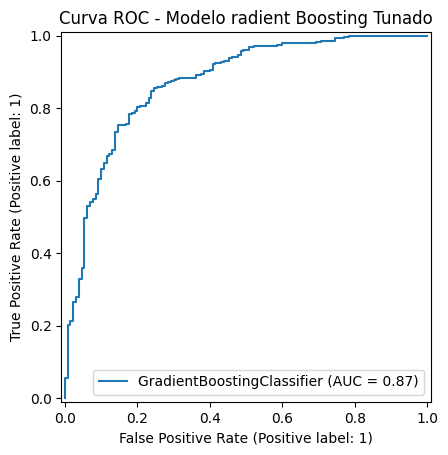

In [33]:
RocCurveDisplay.from_estimator(modelo_gb_final, X_teste, y_teste)
plt.title("Curva ROC - Modelo radient Boosting Tunado")
plt.show()

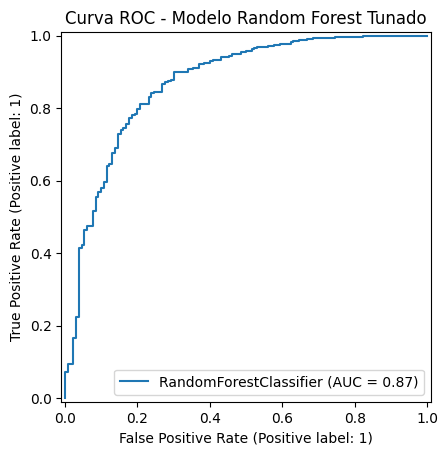

In [34]:
RocCurveDisplay.from_estimator(modelo_rf_final, X_teste, y_teste)
plt.title("Curva ROC - Modelo Random Forest Tunado")
plt.show()

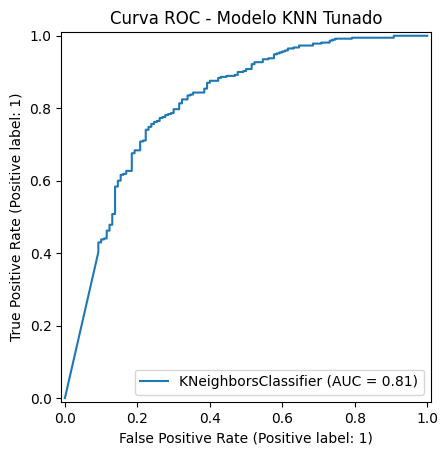

In [35]:
RocCurveDisplay.from_estimator(modelo_knn_final, X_teste, y_teste)
plt.title("Curva ROC - Modelo KNN Tunado")
plt.show()

### Interpretação das curvas ROC

Gradient Boosting e Random Forest apresentaram AUC de aproximadamente 0,87, indicando boa capacidade de separação entre detratores e não detratores.

O KNN apresentou AUC de aproximadamente 0,81, resultado inferior aos demais modelos, embora ainda demonstre capacidade de discriminação superior a uma classificação aleatória.

As curvas mostram que Gradient Boosting e Random Forest possuem desempenho semelhante em termos de separação global das classes.

## Seleção do modelo final

Após a análise das métricas, das matrizes de confusão e das curvas ROC, o Gradient Boosting foi selecionado como modelo final.

O modelo apresentou acurácia próxima de 83%, AUC de aproximadamente 0,87 e recall elevado para a classe `1`, correspondente aos clientes detratores.

Essa característica é relevante para o objetivo do projeto, pois permite identificar a maior quantidade possível de clientes com risco de insatisfação, reduzindo a ocorrência de detratores não reconhecidos pelo modelo.

Embora o Random Forest tenha apresentado maior equilíbrio entre as classes, o Gradient Boosting foi priorizado por sua maior capacidade de detectar clientes detratores.

A escolha considera o contexto de negócio, no qual deixar de identificar um cliente insatisfeito pode representar perda de oportunidade para ações de recuperação e retenção.

# 11. Validação cruzada do modelo final

Após a seleção do Gradient Boosting como modelo final, será realizada uma validação cruzada estratificada com cinco divisões.

O objetivo é verificar se o desempenho do modelo permanece consistente em diferentes subconjuntos dos dados de treino, reduzindo a dependência de uma única divisão entre treino e teste.

Serão avaliadas as métricas de acurácia, precision, recall, F1-score e ROC-AUC.

In [36]:
modelo_final = random_gb.best_estimator_

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_resultados = cross_validate(
    estimator=modelo_final,
    X = X_treino,
    y = y_treino,
    cv= cv,
    scoring= metricas,
    n_jobs= -1
)

In [37]:
# Organizando resultados
cv_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Média': [
        cv_resultados['test_accuracy'].mean(),
        cv_resultados['test_precision'].mean(),
        cv_resultados['test_recall'].mean(),
        cv_resultados['test_f1'].mean(),
        cv_resultados['test_roc_auc'].mean()
    ],
    'Desvio padrão': [
        cv_resultados['test_accuracy'].std(),
        cv_resultados['test_precision'].std(),
        cv_resultados['test_recall'].std(),
        cv_resultados['test_f1'].std(),
        cv_resultados['test_roc_auc'].std()
    ]
})

cv_df.round(4)

,Métrica,Média,Desvio padrão
0,Accuracy,0.8315,0.0183
1,Precision,0.8591,0.0164
2,Recall,0.9244,0.0082
3,F1-score,0.8905,0.0113
4,ROC-AUC,0.8726,0.0171


### Interpretação

O modelo apresentou desempenho consistente durante a validação cruzada.

A acurácia média foi de aproximadamente 83,15%, com desvio-padrão de 1,83 ponto percentual. O recall médio foi de 92,44%, indicando boa capacidade de identificar clientes detratores.

O F1-score médio foi de 89,05%, enquanto a ROC-AUC média alcançou 87,26%, reforçando a capacidade do modelo de separar as duas classes.

Os baixos desvios-padrão observados em todas as métricas indicam que o Gradient Boosting apresenta comportamento estável entre as diferentes divisões dos dados.

Esses resultados reforçam a adequação do modelo para seguir como solução final do projeto.

# 12. Aplicação do modelo ao negócio

Após a validação do modelo final, as probabilidades previstas serão utilizadas para transformar o resultado técnico em informações acionáveis para o e-commerce.

O objetivo desta etapa é identificar clientes com maior risco de insatisfação, priorizar os casos com maior impacto financeiro e recomendar ações de retenção de acordo com os problemas observados na jornada.

In [38]:
dados_resultado = df.copy()

In [39]:
# Gerando a probabilidade do cliente ser detrator
dados_resultado["prob_detrator"] = (
    modelo_final.predict_proba(X_teste)[:, 1]
)

### Segmentação por nível de risco

Os clientes serão agrupados em quatro níveis de risco com base na probabilidade prevista pelo modelo:

- **Baixo:** até 30%;
- **Moderado:** entre 30% e 60%;
- **Alto:** entre 60% e 80%;
- **Crítico:** acima de 80%.

Essa segmentação facilita a definição de diferentes estratégias de acompanhamento e retenção.

In [40]:
dados_resultado["nivel_risco"] = pd.cut(
    dados_resultado["prob_detrator"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=[
        "Baixo",
        "Moderado",
        "Alto",
        "Crítico"
    ],
    include_lowest=True
)

### Identificação dos problemas críticos

Além do nível de risco, serão consideradas três situações críticas identificadas durante a análise exploratória:

- atraso crítico na entrega;
- problema complexo de atendimento;
- reclamação recorrente.

A quantidade de problemas enfrentados por cada cliente será utilizada para tornar a recomendação de ação mais específica.

In [41]:
colunas_problemas = [
    "atraso_critico",
    "problema_complexo",
    "reclamacao_recorrente"
]

dados_resultado["quantidade_problemas"] = (
    dados_resultado[colunas_problemas]
    .sum(axis=1)
)

### Priorização financeira

O indicador `valor_em_risco` combina a probabilidade de o cliente ser detrator com o valor do pedido.

Essa medida funciona como um índice de priorização, destacando clientes que apresentam simultaneamente maior risco de insatisfação e maior relevância financeira.

O valor calculado não representa uma perda financeira garantida, mas uma referência para apoiar a ordem de atendimento.

In [42]:
dados_resultado["valor_em_risco"] = (
    dados_resultado["prob_detrator"]
    * dados_resultado["valor_pedido"]
).round(2)

### Recomendação de ações

As ações recomendadas serão definidas com base na combinação entre o nível de risco e os problemas críticos identificados na jornada.

Clientes com múltiplos problemas receberão ações mais completas e prioritárias, enquanto clientes com risco moderado ou baixo poderão ser acompanhados por estratégias de monitoramento e relacionamento.

In [47]:
def recomendar_acao(linha):
    atraso = linha["atraso_critico"] == 1
    problema = linha["problema_complexo"] == 1
    reclamacao = linha["reclamacao_recorrente"] == 1
    risco = linha["nivel_risco"]

    if atraso and problema and reclamacao:
        return "Atendimento sênior e plano completo de recuperação"

    if reclamacao and problema:
        return "Atendimento especializado e acompanhamento até a resolução"

    if atraso and reclamacao:
        return "Contato prioritário e compensação pela falha logística"

    if atraso and problema:
        return "Atendimento especializado e acompanhamento da entrega"

    if reclamacao:
        return "Analisar a causa recorrente e realizar contato prioritário"

    if atraso:
        return "Pedido de desculpas e benefício no próximo frete"

    if problema:
        return "Encaminhar para atendimento especializado"

    if risco == "Crítico":
        return "Contato preventivo imediato"

    if risco == "Alto":
        return "Acompanhamento preventivo"

    if risco == "Moderado":
        return "Monitoramento ativo e comunicação de relacionamento"

    if risco == "Baixo":
        return "Monitoramento padrão"

    return "Revisar classificação"

In [48]:
dados_resultado["acao_recomendada"] = (
    dados_resultado.apply(
        recomendar_acao,
        axis=1
    )
)

### Sugestão de desconto

O valor do desconto sugerido será calculado a partir do valor em risco.

Para evitar recomendações excessivas, será aplicado um limite máximo de R$ 80,00 por cliente.

Esse valor representa uma simulação para o projeto e, em uma aplicação real, deveria ser validado com base na margem dos produtos, no orçamento disponível e na política comercial da empresa.

In [49]:
dados_resultado["valor_desconto_sugerido"] = (
    dados_resultado["valor_em_risco"] * 0.08
).clip(
    upper=80
).round(2)

### Tabela final de retenção

A tabela final reunirá as principais informações necessárias para apoiar a tomada de decisão:

- probabilidade de o cliente ser detrator;
- nível de risco;
- valor do pedido;
- valor em risco;
- quantidade de problemas críticos;
- ação recomendada;
- desconto sugerido.

Os clientes serão ordenados pela quantidade de problemas e pelo valor em risco, formando uma fila de priorização para as áreas de atendimento e relacionamento.

In [52]:
resultado_retencao = (
    dados_resultado[
        [
            "prob_detrator",
            "nivel_risco",
            "valor_pedido",
            "valor_em_risco",
            "quantidade_problemas",
            "atraso_critico",
            "problema_complexo",
            "reclamacao_recorrente",
            "acao_recomendada",
            "valor_desconto_sugerido"
        ]
    ]
    .sort_values(
        by=[
            "quantidade_problemas",
            "valor_em_risco"
        ],
        ascending=False
    )
)

resultado_retencao.head(5)

,prob_detrator,nivel_risco,valor_pedido,valor_em_risco,quantidade_problemas,atraso_critico,problema_complexo,reclamacao_recorrente,acao_recomendada,valor_desconto_sugerido
986,0.987467,Crítico,1153.70,1139.24,3,1,1,1,Atendimento sênior e plano completo de recuper...,80.00
1466,0.954924,Crítico,1070.81,1022.54,3,1,1,1,Atendimento sênior e plano completo de recuper...,80.00
763,0.924176,Crítico,1094.43,1011.45,3,1,1,1,Atendimento sênior e plano completo de recuper...,80.00
1194,0.891931,Crítico,1103.63,984.36,3,1,1,1,Atendimento sênior e plano completo de recuper...,78.75
1673,0.978040,Crítico,927.01,906.65,3,1,1,1,Atendimento sênior e plano completo de recuper...,72.53


# 13. Salvamento do modelo e do pré-processamento

Após a seleção e validação do modelo final, serão salvos os principais artefatos utilizados na solução.

O modelo preditivo será armazenado para permitir novas previsões sem a necessidade de realizar um novo treinamento.

Também será salvo o pipeline de pré-processamento, responsável por aplicar às novas observações as mesmas transformações utilizadas durante a etapa de modelagem.

Esse cuidado garante consistência entre os dados utilizados no treinamento e os dados recebidos posteriormente em produção.

In [54]:
# Salvando o Modelo Preditivo
joblib.dump(modelo_final, 'modelo_final.pkl')

# Salvando o pipeline de pré-processamento
joblib.dump(full_pipeline, 'pre_processamento.pkl')

['pre_processamento.pkl']

## Considerações finais

Este notebook consolidou a etapa de modelagem do projeto, transformando a base tratada em uma solução preditiva voltada à identificação de clientes detratores.

O processo começou com a definição da variável-alvo e a criação de atributos derivados a partir dos principais padrões identificados na análise exploratória. Em seguida, os dados foram separados entre treino e teste, respeitando a distribuição das classes, e submetidos a um fluxo de pré-processamento composto por padronização das variáveis numéricas e codificação da variável categórica.

Diferentes algoritmos de classificação foram treinados e comparados sob as mesmas condições. Os modelos com melhor desempenho avançaram para a etapa de otimização de hiperparâmetros, realizada com validação cruzada e F1 Macro como métrica principal, garantindo uma avaliação mais equilibrada entre detratores e não detratores.

Após a análise conjunta das métricas, dos relatórios de classificação, das matrizes de confusão e das curvas ROC, o Gradient Boosting foi selecionado como modelo final. A escolha considerou sua capacidade de identificar clientes detratores, sua boa separação entre as classes e a estabilidade observada durante a validação cruzada.

Além da previsão, foi desenvolvida uma camada de aplicação ao negócio. As probabilidades geradas pelo modelo foram convertidas em níveis de risco, indicadores de prioridade financeira e recomendações de ação baseadas nos problemas enfrentados por cada cliente.

Essa abordagem permite utilizar o modelo não apenas para classificar clientes, mas também para apoiar a priorização de atendimentos, a definição de estratégias de recuperação e a tomada de decisão no e-commerce.

Por fim, o modelo final e o pipeline de pré-processamento foram salvos para reutilização em novas previsões, garantindo consistência entre o treinamento e o uso futuro da solução.

O resultado final é uma solução completa, que integra preparação de dados, engenharia de atributos, Machine Learning, validação estatística e aplicação prática ao contexto de negócio.